In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
import json
from PIL import Image
import tensorflow as tf
import tensorflow_hub as hub
import tensorflow_datasets as tfds

print("TensorFlow version:", tf.__version__)

2026-05-03 14:19:35.605113: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777817975.803172      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777817975.867635      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777817976.358477      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777817976.358515      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777817976.358518      57 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0


In [2]:
(train_ds, val_ds, test_ds), info = tfds.load(
    'oxford_flowers102',
    split=['train', 'validation', 'test'],
    as_supervised=True,
    with_info=True
)

print(f"عدد صور التدريب: {info.splits['train'].num_examples}")
print(f"عدد صور التحقق: {info.splits['validation'].num_examples}")
print(f"عدد صور الاختبار: {info.splits['test'].num_examples}")
print(f"عدد الأصناف (الزهور): {info.features['label'].num_classes}")

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

...

Shuffling /root/tensorflow_datasets/oxford_flowers102/incomplete.046QKS_2.1.1/oxford_flowers102-test.tfrecord*…

Generating validation examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_flowers102/incomplete.046QKS_2.1.1/oxford_flowers102-validation.tfr…

Dataset oxford_flowers102 downloaded and prepared to /root/tensorflow_datasets/oxford_flowers102/2.1.1. Subsequent calls will reuse this data.
عدد صور التدريب: 1020
عدد صور التحقق: 1020
عدد صور الاختبار: 6149
عدد الأصناف (الزهور): 102


I0000 00:00:1777818052.680433      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777818052.686363      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


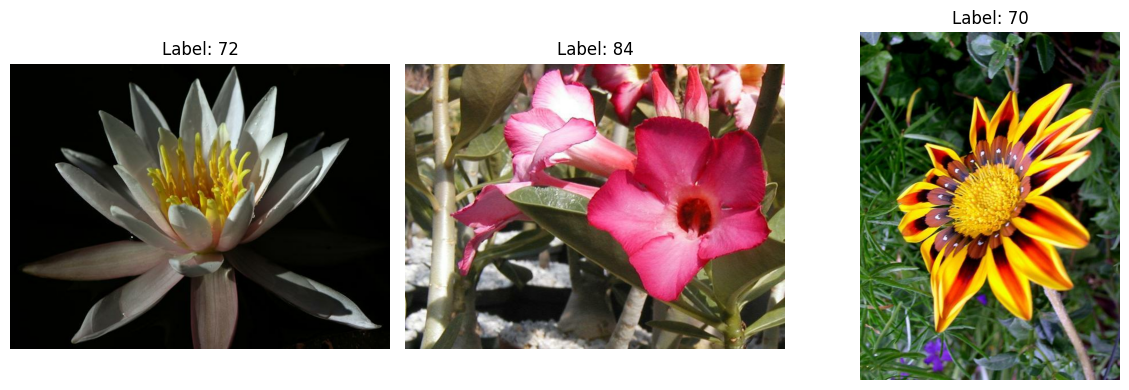

Image shape: (500, 667, 3), Label: 72
Image shape: (500, 666, 3), Label: 84
Image shape: (670, 500, 3), Label: 70


In [3]:
# Display 3 random images from training set
plt.figure(figsize=(12, 4))
for i, (image, label) in enumerate(train_ds.take(3)):
    plt.subplot(1, 3, i+1)
    plt.imshow(image)
    plt.title(f"Label: {label.numpy()}")
    plt.axis('off')
plt.tight_layout()
plt.show()

# Print image shapes
for image, label in train_ds.take(3):
    print(f"Image shape: {image.shape}, Label: {label.numpy()}")

In [6]:
# ==================================================
# CORRECT WAY TO LOAD LABEL MAP ON KAGGLE
# ==================================================

# Method 1: If you uploaded the file as a dataset
import json
import os

# First, let's find where the file actually is
print("Current working directory:", os.getcwd())
print("Files in /kaggle/input:", os.listdir('/kaggle/input'))

# Try to find the correct path (adjust based on your dataset name)
# Option A: If your dataset is named "label-json"
json_path = '/kaggle/input/label-json/label_map.json'

# Option B: If the above doesn't work, search for it
if not os.path.exists(json_path):
    # Search recursively for label_map.json
    for root, dirs, files in os.walk('/kaggle/input'):
        if 'label_map.json' in files:
            json_path = os.path.join(root, 'label_map.json')
            print(f"Found at: {json_path}")
            break

# Load the JSON file
try:
    with open(json_path, 'r') as f:
        class_names = json.load(f)
    print("✅ Label map loaded successfully!")
    print(f"Number of classes: {len(class_names)}")
    
    # Display first 5 flower names
    print("\nSample flower names:")
    for i in range(min(5, len(class_names))):
        print(f"  Class {i}: {class_names[str(i)]}")
        
except FileNotFoundError:
    print(f"❌ File not found at {json_path}")
    print("\nAlternative: Download the file directly from the internet:")
    
    # Download directly (most reliable method on Kaggle)
    import urllib.request
    url = "https://storage.googleapis.com/download.tensorflow.org/data/oxford_flowers102/labels.json"
    urllib.request.urlretrieve(url, 'labels.json')
    
    with open('labels.json', 'r') as f:
        class_names = json.load(f)
        # Convert keys to int/str as needed
        class_names = {int(k): v for k, v in class_names.items()}
    
    print("✅ Downloaded and loaded successfully!")

Current working directory: /kaggle/working
Files in /kaggle/input: ['datasets']
Found at: /kaggle/input/datasets/leyanbuirat/label-json/label_map.json
✅ Label map loaded successfully!
Number of classes: 102

Sample flower names:
  Class 0: pink primrose
  Class 1: hard-leaved pocket orchid
  Class 2: canterbury bells
  Class 3: sweet pea
  Class 4: english marigold


In [8]:
IMG_SIZE = 224
BATCH_SIZE = 32

def preprocess_image(image, label):
    image = tf.cast(image, tf.float32)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = image / 255.0
    return image, label

print("✅ Preprocessing function ready")

✅ Preprocessing function ready


In [9]:
train_data = train_ds.map(preprocess_image).batch(BATCH_SIZE).prefetch(1)
val_data = val_ds.map(preprocess_image).batch(BATCH_SIZE).prefetch(1)
test_data = test_ds.map(preprocess_image).batch(BATCH_SIZE).prefetch(1)

print(f"✅ Data prepared: {len(list(train_data))} training batches")

✅ Data prepared: 32 training batches


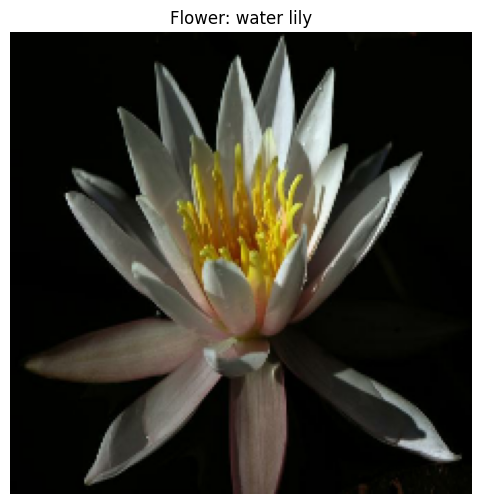

Label number: 72
Flower name: water lily


In [11]:
# Display a processed image with its flower name
for image, label in train_data.take(1):
    first_image = image[0].numpy()
    first_label = label[0].numpy()
    
    plt.figure(figsize=(6, 6))
    plt.imshow(first_image)
    # ✅ FIX: Convert label to string (or int based on your class_names)
    plt.title(f"Flower: {class_names[str(first_label)]}")
    plt.axis('off')
    plt.show()
    
    print(f"Label number: {first_label}")
    print(f"Flower name: {class_names[str(first_label)]}")

In [14]:
def create_model():
    """
    Create a model using MobileNetV2 from Keras Applications
    This avoids TensorFlow Hub compatibility issues
    """
    # Load pre-trained MobileNetV2 (without top classification layer)
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,  # Remove the original classification head
        weights='imagenet'   # Load pre-trained weights from ImageNet
    )
    
    # Freeze the base model so we don't retrain it
    base_model.trainable = False
    
    # Build the complete model
    model = tf.keras.Sequential([
        base_model,                              # Feature extractor
        tf.keras.layers.GlobalAveragePooling2D(), # Reduce dimensions
        tf.keras.layers.Dense(128, activation='relu'),  # New learning layer
        tf.keras.layers.Dropout(0.2),            # Prevent overfitting
        tf.keras.layers.Dense(102, activation='softmax')  # 102 flower types
    ])
    
    return model

# Create the model
model = create_model()
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 102)            │        13,158 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,435,110 (9.29 MB)

 Trainable params: 177,126 (691.90 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [15]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("✅ Model compiled successfully!")

✅ Model compiled successfully!


In [16]:
EPOCHS = 10

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS
)

print("✅ Training completed!")

Epoch 1/10


I0000 00:00:1777818830.554060     156 service.cc:152] XLA service 0x7e73dc012310 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777818830.554105     156 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1777818830.554109     156 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1777818831.634355     156 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-05-03 14:34:00.812684: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-03 14:34:00.950601: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1777818843.247075     156 device_co

31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.0221 - loss: 4.7087

2026-05-03 14:34:13.468109: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-03 14:34:13.605741: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


32/32 ━━━━━━━━━━━━━━━━━━━━ 39s 682ms/step - accuracy: 0.0236 - loss: 4.6976 - val_accuracy: 0.1892 - val_loss: 4.0354
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 0.2775 - loss: 3.5541 - val_accuracy: 0.4039 - val_loss: 2.9175
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 0.5053 - loss: 2.3752 - val_accuracy: 0.5520 - val_loss: 2.1389
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 0.6401 - loss: 1.6614 - val_accuracy: 0.6225 - val_loss: 1.7213
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - accuracy: 0.7398 - loss: 1.1652 - val_accuracy: 0.6686 - val_loss: 1.4668
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 0.7896 - loss: 0.8874 - val_accuracy: 0.7088 - val_loss: 1.2586
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 0.8721 - loss: 0.6949 - val_accuracy: 0.7265 - val_loss: 1.1510
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - accuracy: 0.9019 - loss: 0.4729 - val_accuracy: 0.7373 - val_loss: 

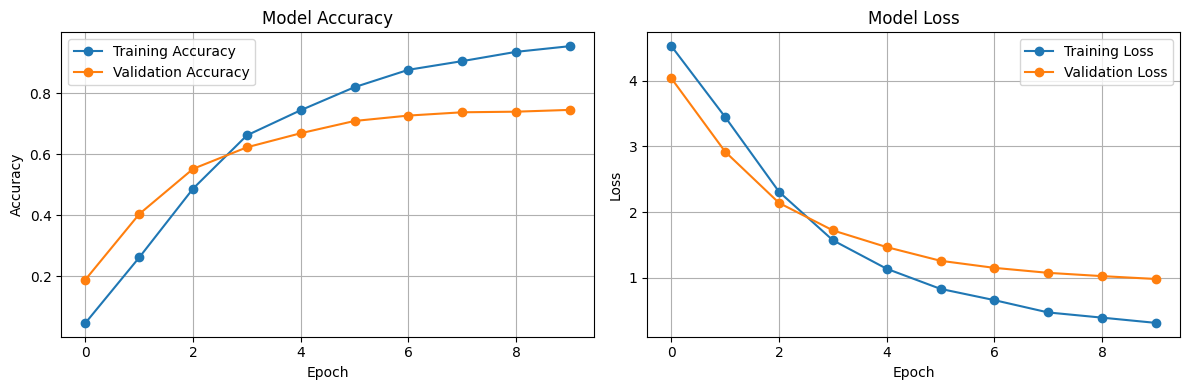

Final Training Accuracy: 0.9539
Final Validation Accuracy: 0.7451


In [17]:
plt.figure(figsize=(12, 4))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='o')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Print final values
print(f"Final Training Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")

In [18]:
# Evaluate on test set
test_loss, test_accuracy = model.evaluate(test_data)

print(f"\n{'='*50}")
print(f"TEST RESULTS:")
print(f"  Loss: {test_loss:.4f}")
print(f"  Accuracy: {test_accuracy:.4f}")
print(f"{'='*50}\n")

if test_accuracy > 0.70:
    print("✅ Great! Model achieved >70% accuracy on unseen test images!")
else:
    print("⚠️ Try increasing epochs or adjusting the model architecture.")

192/193 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.7282 - loss: 1.1129

2026-05-03 14:37:03.831968: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-03 14:37:03.971732: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-03 14:37:04.109168: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-03 14:37:04.245624: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


193/193 ━━━━━━━━━━━━━━━━━━━━ 17s 86ms/step - accuracy: 0.7282 - loss: 1.1131

TEST RESULTS:
  Loss: 1.1302
  Accuracy: 0.7261

✅ Great! Model achieved >70% accuracy on unseen test images!


In [20]:
# Save the model
model.save('flower_classifier.h5')
print("Model saved as 'flower_classifier.h5'")

#save in TensorFlow SavedModel format
model.export('saved_model')
print("Model also saved in SavedModel format in 'saved_model' folder")

Model saved as 'flower_classifier.h5'
INFO:tensorflow:Assets written to: saved_model/assets


INFO:tensorflow:Assets written to: saved_model/assets


Saved artifact at 'saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_155')
Output Type:
  TensorSpec(shape=(None, 102), dtype=tf.float32, name=None)
Captures:
  139036483646672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139036483645904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139036483648016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139036483646096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139036483646864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139036483645136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139036483643984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139036483643792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139036483644944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139036483646288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1390364836478

In [25]:
# Ensure class_names has integer keys for easier access
if isinstance(list(class_names.keys())[0], str):
    print("Converting class_names keys from string to int...")
    class_names = {int(k): v for k, v in class_names.items()}
    print("✅ Converted successfully!")
else:
    print("✅ class_names already has integer keys")

# Test the conversion
test_key = 0
print(f"Class 0: {class_names[test_key]}")

Converting class_names keys from string to int...
✅ Converted successfully!
Class 0: pink primrose


In [26]:
def predict_image(image_path, model, top_k=5):
    """
    Load an image from path, preprocess it, and return top K predictions.
    """
    # Load and preprocess the image
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = img / 255.0
    img = tf.expand_dims(img, axis=0)
    
    # Get predictions
    predictions = model.predict(img, verbose=0)[0]
    
    # Get top K predictions
    top_k_indices = np.argsort(predictions)[-top_k:][::-1]
    top_k_probs = predictions[top_k_indices]
    
    # Now class_names has integer keys, so direct access works
    top_k_names = [class_names[idx] for idx in top_k_indices]
    
    return top_k_probs, top_k_names

print("✅ Prediction function ready")

✅ Prediction function ready


True flower: barbeton daisy
True label number: 40

Top 3 Predictions:
  1. barbeton daisy: 0.8189 (81.89%)
  2. sunflower: 0.0621 (6.21%)
  3. gazania: 0.0263 (2.63%)


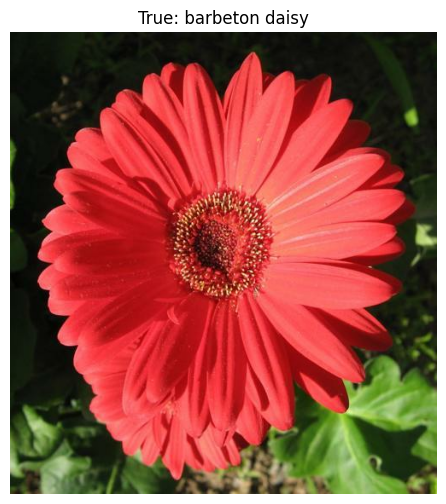

In [28]:
# Ignore CUDA timeout warnings (they don't affect results)
import warnings
warnings.filterwarnings('ignore')

# Test on a random image from test set
for image, label in test_ds.take(1):
    # Save image temporarily
    img_uint8 = tf.cast(image, tf.uint8)
    tf.io.write_file('/tmp/test_image.jpg', tf.io.encode_jpeg(img_uint8))
    
    # Make prediction
    probs, names = predict_image('/tmp/test_image.jpg', model, top_k=3)
    
    # Display results
    print(f"True flower: {class_names[label.numpy()]}")
    print(f"True label number: {label.numpy()}")
    print("\nTop 3 Predictions:")
    for i, (prob, name) in enumerate(zip(probs, names)):
        print(f"  {i+1}. {name}: {prob:.4f} ({prob*100:.2f}%)")
    
    # Display the image
    plt.figure(figsize=(6, 6))
    plt.imshow(image)
    plt.title(f"True: {class_names[label.numpy()]}")
    plt.axis('off')
    plt.show()

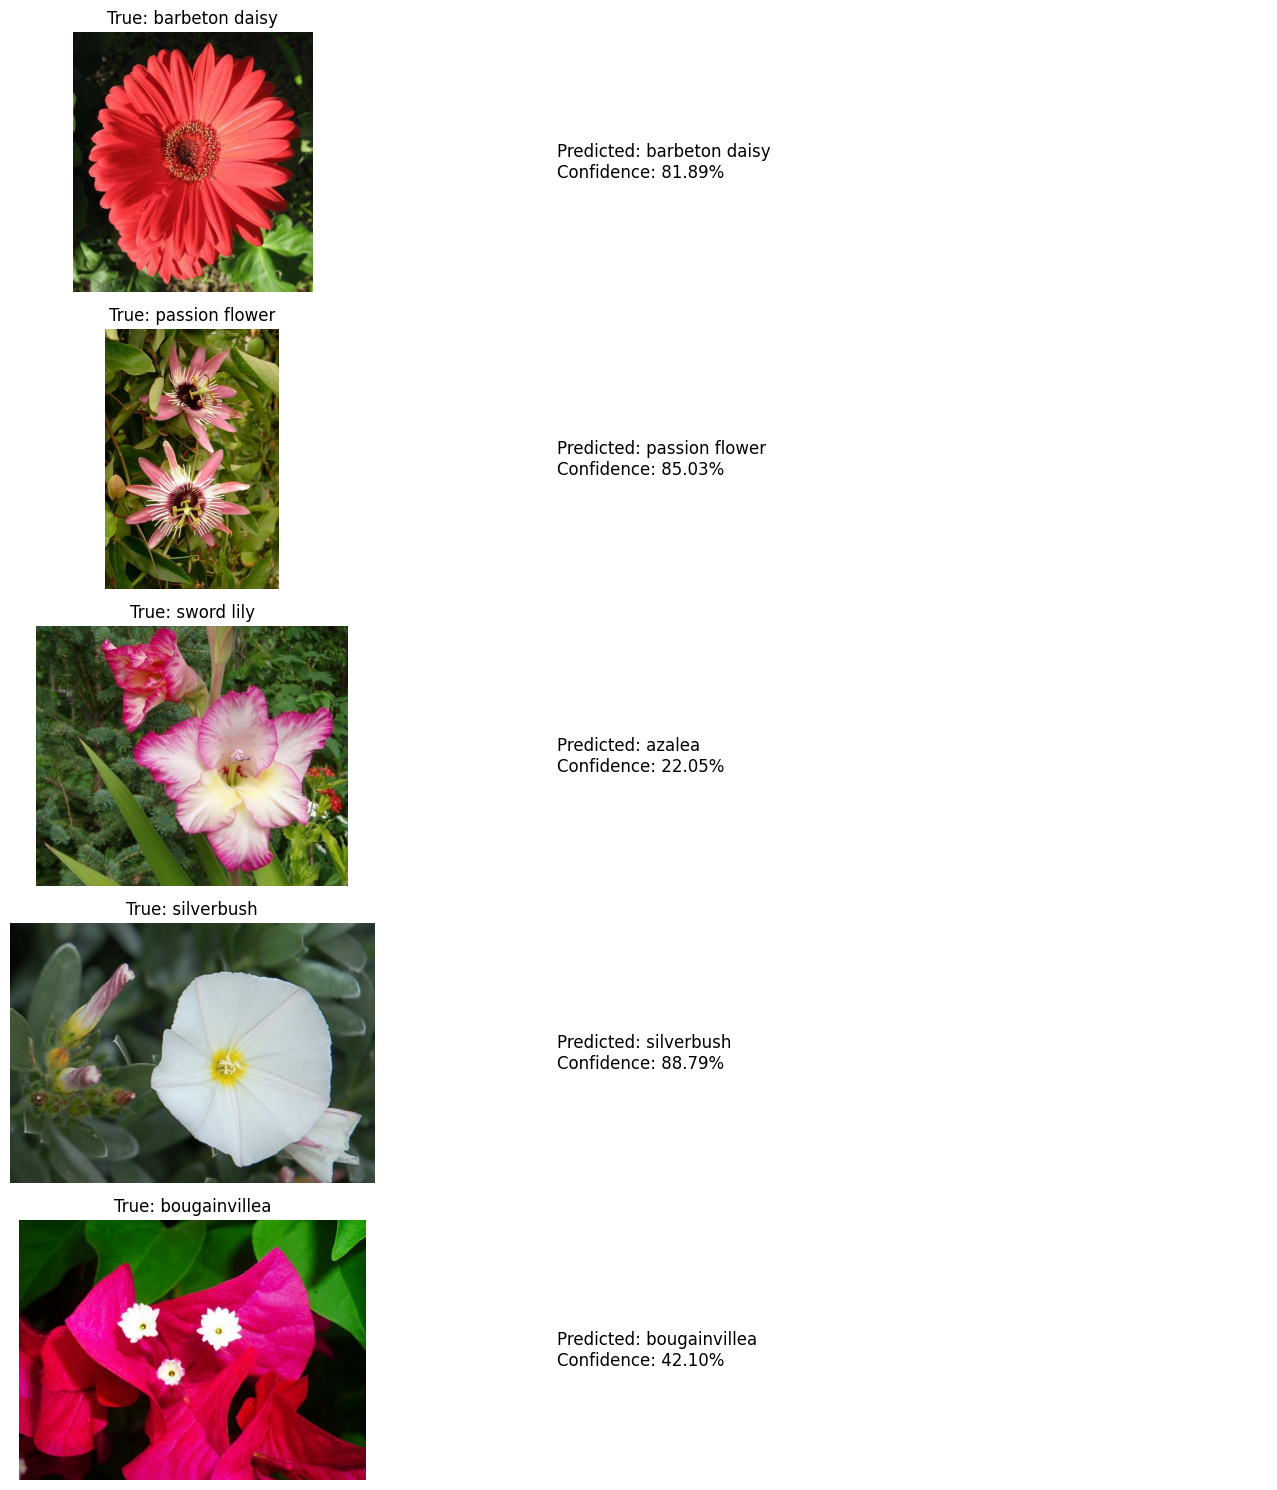


ACCURACY: 4/5 = 80.00%


In [29]:
# Test on multiple images from test set
def test_multiple_images(num_images=5):
    """
    Test the model on multiple random images from test set
    """
    correct = 0
    total = 0
    
    plt.figure(figsize=(15, 3 * num_images))
    
    for i, (image, label) in enumerate(test_ds.take(num_images)):
        # Save image temporarily
        img_uint8 = tf.cast(image, tf.uint8)
        tf.io.write_file('/tmp/test_img.jpg', tf.io.encode_jpeg(img_uint8))
        
        # Make prediction
        probs, names = predict_image('/tmp/test_img.jpg', model, top_k=1)
        
        # Get predicted label
        predicted_label = list(class_names.keys())[list(class_names.values()).index(names[0])]
        true_label = label.numpy()
        
        is_correct = (predicted_label == true_label)
        if is_correct:
            correct += 1
        total += 1
        
        # Display image
        plt.subplot(num_images, 2, 2*i + 1)
        plt.imshow(image)
        plt.title(f"True: {class_names[true_label]}")
        plt.axis('off')
        
        # Display prediction result
        plt.subplot(num_images, 2, 2*i + 2)
        pred_text = f"Predicted: {names[0]}\nConfidence: {probs[0]:.2%}"
        plt.text(0.1, 0.5, pred_text, fontsize=12, verticalalignment='center')
        plt.axis('off')
        if is_correct:
            plt.gca().set_facecolor('#90EE90')  # Light green for correct
        else:
            plt.gca().set_facecolor('#FFCCCC')  # Light red for wrong
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n{'='*40}")
    print(f"ACCURACY: {correct}/{total} = {correct/total:.2%}")
    print(f"{'='*40}")

# Run the test
test_multiple_images(num_images=5)

In [30]:
# Save the model in Keras format for easy loading
model.save('flower_classifier.h5')
print("Model saved as 'flower_classifier.h5'")

# Optional: Load the model back to verify it works
loaded_model = tf.keras.models.load_model('flower_classifier.h5')
print("Model loaded successfully!")

# Verify loaded model works
test_loss, test_accuracy = loaded_model.evaluate(test_data, verbose=0)
print(f"Loaded model test accuracy: {test_accuracy:.4f}")

Model saved as 'flower_classifier.h5'


Model loaded successfully!
Loaded model test accuracy: 0.7261


In [31]:
import urllib.request

def predict_from_url(image_url, model, top_k=3):
    """
    Download an image from URL and predict its flower type
    """
    # Download image from URL
    image_path = '/tmp/url_image.jpg'
    urllib.request.urlretrieve(image_url, image_path)
    
    # Make prediction
    probs, names = predict_image(image_path, model, top_k=top_k)
    
    # Display results
    print(f"\n{'='*50}")
    print(f"PREDICTIONS for image from URL:")
    print(f"{'='*50}")
    for i, (prob, name) in enumerate(zip(probs, names)):
        print(f"{i+1}. {name}: {prob:.4f} ({prob*100:.2f}%)")
    
    # Display the image
    img = plt.imread(image_path)
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.title(f"Image from URL")
    plt.axis('off')
    plt.show()
    
    return names[0]  # Return top prediction

# Example usage (uncomment to test):
# predict_from_url('https://example.com/flower.jpg', model)
print("✅ URL prediction function ready")

✅ URL prediction function ready


In [32]:
# Convert model to TensorFlow Lite format for mobile deployment
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Save the TFLite model
with open('flower_classifier.tflite', 'wb') as f:
    f.write(tflite_model)

print("Model converted to TensorFlow Lite!")
print(f"TFLite model size: {len(tflite_model) / 1024:.2f} KB")

# Optional: Test TFLite model
interpreter = tf.lite.Interpreter(model_content=tflite_model)
interpreter.allocate_tensors()
print("TFLite model is valid and ready for mobile deployment")

INFO:tensorflow:Assets written to: /tmp/tmpi6cs2krb/assets


INFO:tensorflow:Assets written to: /tmp/tmpi6cs2krb/assets


Saved artifact at '/tmp/tmpi6cs2krb'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_155')
Output Type:
  TensorSpec(shape=(None, 102), dtype=tf.float32, name=None)
Captures:
  139036483646672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139036483645904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139036483648016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139036483646096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139036483646864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139036483645136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139036483643984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139036483643792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139036483644944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139036483646288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13903648

W0000 00:00:1777820074.701509      57 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1777820074.701546      57 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1777820074.844118      57 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


In [34]:
# Final summary of the model performance
print("FINAL MODEL SUMMARY".center(60))

print(f"\nDataset Information:")
print(f"   - Training images: {info.splits['train'].num_examples}")
print(f"   - Validation images: {info.splits['validation'].num_examples}")
print(f"   - Test images: {info.splits['test'].num_examples}")
print(f"   - Flower classes: {len(class_names)}")

print(f"\nModel Architecture:")
print(f"   - Base model: MobileNetV2 (pretrained on ImageNet)")
print(f"   - Input shape: {IMG_SIZE}x{IMG_SIZE}x3")
print(f"   - Trainable parameters: {model.count_params():,}")

print(f"\nModel Performance:")
if 'test_accuracy' in dir():
    print(f"   - Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
if 'history' in dir():
    final_train_acc = history.history['accuracy'][-1]
    final_val_acc = history.history['val_accuracy'][-1]
    print(f"   - Final Training Accuracy: {final_train_acc:.4f}")
    print(f"   - Final Validation Accuracy: {final_val_acc:.4f}")

print(f"\nSaved Files:")
print(f"   - flower_classifier.h5 (Keras model)")
print(f"   - saved_model/ (TensorFlow SavedModel)")
print(f"   - flower_classifier.tflite (Mobile model)")

print(" Model is ready for deployment!")


                    FINAL MODEL SUMMARY                     

Dataset Information:
   - Training images: 1020
   - Validation images: 1020
   - Test images: 6149
   - Flower classes: 102

Model Architecture:
   - Base model: MobileNetV2 (pretrained on ImageNet)
   - Input shape: 224x224x3
   - Trainable parameters: 2,435,110

Model Performance:
   - Test Accuracy: 0.7261 (72.61%)
   - Final Training Accuracy: 0.9539
   - Final Validation Accuracy: 0.7451

Saved Files:
   - flower_classifier.h5 (Keras model)
   - saved_model/ (TensorFlow SavedModel)
   - flower_classifier.tflite (Mobile model)
 Model is ready for deployment!
